# Exploration of Rabi Oscillations and Decoherence with Bloch Sphere Visualization

In [1]:
import numpy as np
from scipy.linalg import expm
import scipy.linalg as la
import matplotlib.pyplot as plt
! pip install qutip
from qutip import Bloch, about, basis, mesolve, sigmam, sigmax, sigmay, sigmaz, destroy,sigmap

$H = \omega_0 \frac {\hbar}{2} \sigma_z + \omega_1 \frac {\hbar}{2} (cos(\omega t) \sigma_x + sin(\omega t) \sigma_y) $

In [2]:
# setting parameters and defining the Hamiltonian                              
            
def hamiltonian(w_0, w_1, w, t):                                             # time steps
    H = np.zeros((len(t), 2, 2), dtype=complex)                              # Hamiltonian initialization
    H[:, 0, 0] = w_0
    H[:, 1, 1] = -w_0
    H[:, 0, 1] = w_1 * np.exp(-1j * w * t)
    H[:, 1, 0] = w_1 * np.exp(1j * w * t)
    return H

In [3]:
# setting up a test state
t_array = np.arange(1,10,0.01)  
H_res = hamiltonian(1,1,2,t_array)
H_hdamp = hamiltonian(5,5,10,t_array)
H_ldamp = hamiltonian(0.4,0.4,0.8,t_array)
H_off = hamiltonian(1,1,4,t_array)

psi_test = np.array([1,0])
psi1_test = np.array([0,1])

In [4]:
# calculating time evolved state

def psi_t(H, psi_0, t):
    psi = psi_0.astype(complex)
    dt = t[1] - t[0]
    psi_t = []
    for i in range(len(t)):
        psi_t.append(psi)
        U = expm(-1j * H[i] * dt)
        psi = U @ psi
    return psi_t


In [5]:
psi_t_res = psi_t(H_res, psi_test,t_array)
psi_t_hdamp = psi_t(H_hdamp, psi_test,t_array)
psi_t_ldamp = psi_t(H_ldamp, psi_test,t_array)
psi_t_off = psi_t(H_off, psi_test,t_array)

In [6]:
def prob_t(H, psi1,psi2, t):
    probs = []
    psi1 = psi1.copy()
    dt = t[1] - t[0]
    for i in range(len(t)):
        amp = np.vdot(psi2, psi1[i])        # <1|psi(t)>
        probs.append(np.abs(amp)**2)
    return probs

In [7]:
prob_t_res = prob_t(H_res, psi_t_res, psi1_test, t_array)
prob_t_hdamp = prob_t(H_hdamp, psi_t_hdamp, psi1_test,t_array)
prob_t_ldamp = prob_t(H_ldamp, psi_t_ldamp, psi1_test,t_array)
prob_t_off = prob_t(H_off, psi_t_off, psi1_test,t_array)


<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_58188/3043280547.py:8: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$<1|\psi(t)>$')


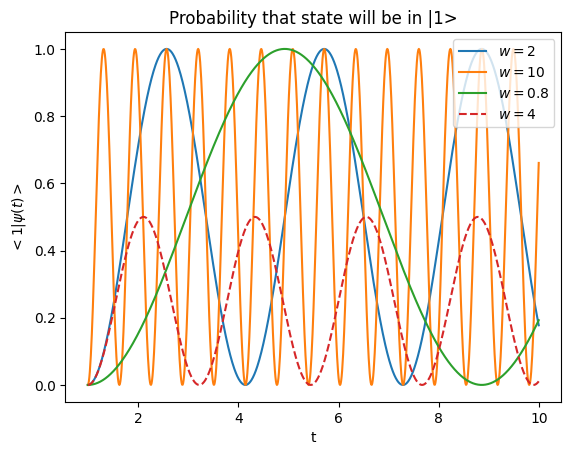

In [8]:
plt.plot(t_array, prob_t_res, label = '$w = 2$')
plt.plot(t_array, prob_t_hdamp, label = '$w = 10$')
plt.plot(t_array, prob_t_ldamp, label = '$w = 0.8$')
plt.plot(t_array, prob_t_off, label = '$w = 4$', ls = '--')

plt.title('Probability that state will be in |1>')
plt.xlabel('t')
plt.ylabel('$<1|\psi(t)>$')
plt.legend(loc = 'upper right')
plt.show()

So far I have looked at an idealized system where there is no noise or coupling to the environment so these oscillations would continue forever, however this is not realistic. There are two types of noise that I would like to look at: 

1. Spontaneous Emission (Relaxation $T_1$)
2. Pure Dephasing ($T_2$)


To do this I will need to move away from the State Vector picture and use the Density Matrix to calculate the evolution of the system.

$ H = \frac{\Delta}{2} \sigma_x$ , $C = \sqrt g  \sigma_z$

Where H is the Hamiltonian in the frame of the spin (before we were using the expiermental/lab frame) and C is the collapse operator with dissipation coefficient g.

Starting by adding simple bit-flip noise, this corresponds to coupling the state to noise along the x-axis, and results in random flips from |0> -> |1> and |1> -> |0>. This type of noise is symmetric.

In [9]:
# coefficients
delta = 2 * np.pi
g = 0.25

# hamiltonian
H = delta / 2.0 * sigmax()

# list of collapse operators
c_ops = [np.sqrt(g) * sigmaz()]                  #dephasing

# initial statec_ops = [np.sqrt(g) * sigmaz()]
psi0 = basis(2, 0)   #ground state

# times
tlist = np.linspace(0, 5, 100)

In [10]:
res = mesolve(H, psi0, tlist, c_ops, [sigmaz()])    #expectation value for sigma_z

/Users/lilahskye/miniconda3/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [11]:
sz_analytic = np.cos(2 * np.pi * tlist) * np.exp(-tlist * g)   # analytical solution for expectation value of sz


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_58188/3941443578.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Time"), plt.ylabel("$<\sigma_z>$")


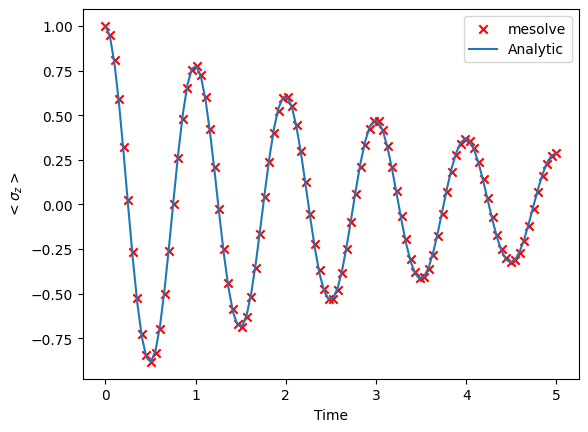

In [12]:
plt.scatter(tlist, res.expect[0], c="r", marker="x", label="mesolve")
plt.plot(tlist, sz_analytic, label="Analytic")
plt.xlabel("Time"), plt.ylabel("$<\sigma_z>$")
plt.legend();

Before we were looking at the probability of starting in state |0> and ending up in |1> after a time t. Because this was a probability, we expected the value to be between 0 and 1. Now, using the density matrix formulism we are looking at $<\sigma_z>$ which represents the probability that the state is either in |0> or |1>, correspodning to a value of 1 and -1 respectively.

My interpretation: the noise caused by the random bit flips means we lose certainty in what state the qubit is in over time. We start knowing it is in |0> and in the absence of noise we can predict the periodic oscillations to know when it returns and when it is in |1>. Now, with the noise, we lose the ability to predict becuase there is now always some probability that the state is in either state.

**Is this classical randomness or a quantum superposition?**

Now let's look at energy relaxation (spontaneous emission) which corresponds to |1> -> |0> transitions.

In [13]:
# list of collapse operators
c_ops_se = [np.sqrt(g) * sigmam()]             #spontaneous emission
res_se = mesolve(H, psi0, tlist, c_ops_se, [sigmaz()])    #expectation value for sigma_z

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_58188/1580469085.py:5: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Time"), plt.ylabel("$<\sigma_z>$")


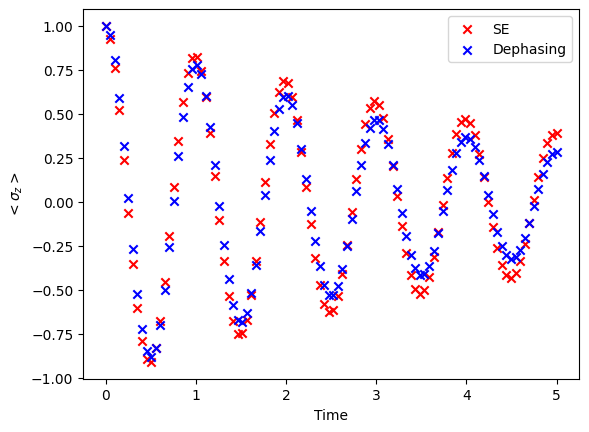

In [14]:
plt.scatter(tlist, res_se.expect[0], c="r", marker="x", label="SE")
plt.scatter(tlist, res.expect[0], c="b", marker="x", label="Dephasing")

#plt.plot(tlist, sz_analytic, label="Analytic")
plt.xlabel("Time"), plt.ylabel("$<\sigma_z>$")
plt.legend();


In [15]:
# In 3D

result = mesolve(H, psi0, tlist, [], [sigmax(), sigmay(), sigmaz()])
result_bf = mesolve(H, psi0, tlist,  [np.sqrt(g) * sigmax()] , [sigmax(), sigmay(), sigmaz()])
result_se = mesolve(H, psi0, tlist,  [np.sqrt(g) * sigmam()] , [sigmax(), sigmay(), sigmaz()])

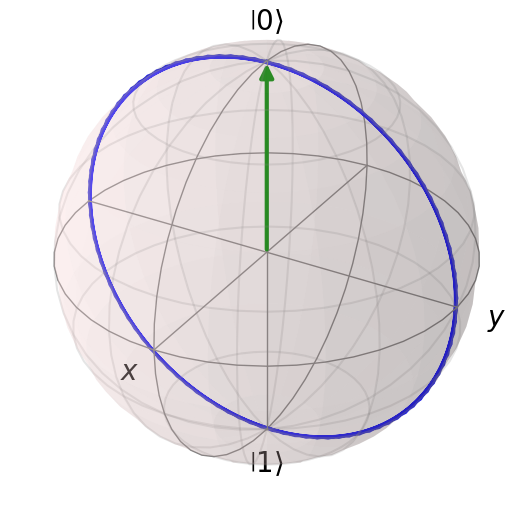

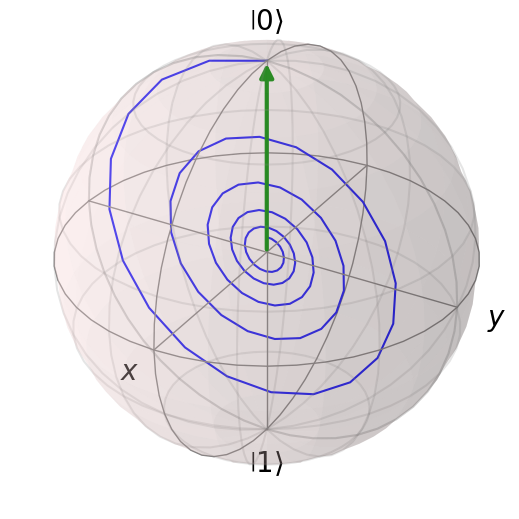

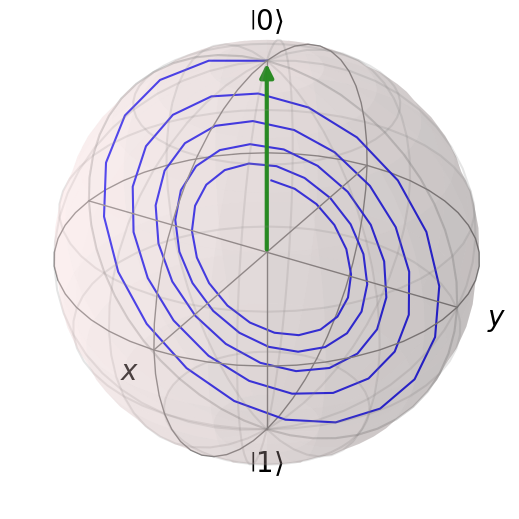

In [16]:
# Extract expectation values for pauli matrices
exp_sx_circ, exp_sy_circ, exp_sz_circ = result.expect
exp_sx_circ, exp_sy_circ, exp_sz_circ = (
    np.array(exp_sx_circ),
    np.array(exp_sy_circ),
    np.array(exp_sz_circ),
)

exp_sx_bf, exp_sy_bf, exp_sz_bf = result_bf.expect
exp_sx_bf, exp_sy_bf, exp_sz_bf = (
    np.array(exp_sx_bf),
    np.array(exp_sy_bf),
    np.array(exp_sz_bf),
)

exp_sx_se, exp_sy_se, exp_sz_se = result_se.expect
exp_sx_se, exp_sy_se, exp_sz_se = (
    np.array(exp_sx_se),
    np.array(exp_sy_se),
    np.array(exp_sz_se),
)


# Create Bloch sphere plot
sphere = Bloch()
sphere.add_points([exp_sx_circ, exp_sy_circ, exp_sz_circ], meth="l")
sphere.add_states(psi0)
sphere.show()

sphere2 = Bloch()
sphere2.add_points([exp_sx_bf, exp_sy_bf, exp_sz_bf], meth="l")
sphere2.add_states(psi0)
sphere2.show()

sphere3 = Bloch()
sphere3.add_points([exp_sx_se, exp_sy_se, exp_sz_se], meth="l")
sphere3.add_states(psi0)
sphere3.show()



As a sanity check: let's check the same behavior for a hamiltonian that is proportional to $\sigma_z$. In that case, with no collapse operators, we should see no motion and with the $\sigma_x$ collapse operator (bit-flip) we should see decay towards 0. With the $\sigma_-$ operator (spontaneous emission) we should see decay towards the ground state ($<\sigma_z>$ -> +1).

In [17]:
H_stat = delta / 2.0 * sigmaz()
tlist = np.linspace(0, 10, 100)
psi0= basis(2,0)                                    # excited state

# list of collapse operators
c_ops = [np.sqrt(g) * sigmaz()]                  #dephasing
c_ops_bf = [np.sqrt(g) * sigmax()]               #bit-flip
c_ops_se = [np.sqrt(g) * sigmam()]               #spontaneous emission

res_stat = mesolve(H_stat, psi0, tlist, [], [sigmaz()])    #expectation value for sigma_z
res_dp = mesolve(H_stat, psi0, tlist, c_ops, [sigmaz()])    #expectation value for sigma_z
res_bf = mesolve(H_stat, psi0, tlist, c_ops_bf, [sigmaz()])
res_se = mesolve(H_stat, psi0, tlist, [np.sqrt(g) * sigmam()] , [sigmaz()])    #expectation value for sigma_z

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_58188/2598456213.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Time"), plt.ylabel("$<\sigma_z>$")


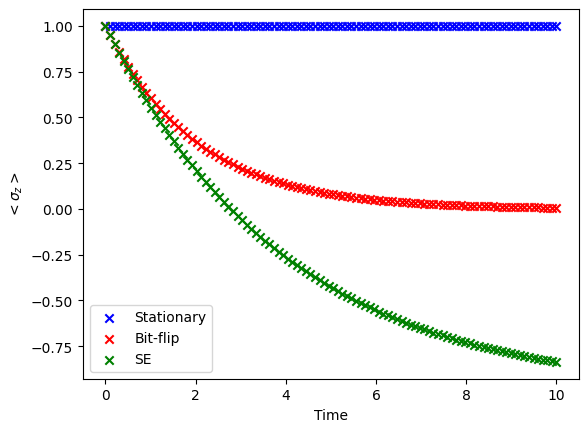

In [18]:
plt.scatter(tlist, res_stat.expect[0], c="b", marker="x", label="Stationary")
plt.scatter(tlist, res_bf.expect[0], c="r", marker="x", label="Bit-flip")
plt.scatter(tlist, res_se.expect[0], c="g", marker="x", label="SE")
#plt.scatter(tlist, res_dp.expect[0], c="b", marker="x", label="Dephasing")

#plt.plot(tlist, sz_analytic, label="Analytic")
plt.xlabel("Time"), plt.ylabel("$<\sigma_z>$")
plt.legend()



So far I have looked at the situation where the system has a drive strength in the x-direction and experiences dephasing, relaxation, and bit-flip noise. Now I want to look at detuning, which is a coherent, effect due to the frequency mismatch between the drive and the qubit. 

In [19]:
# coefficients
omega = 2 * np.pi
delta = 0.1

# hamiltonian
H = - delta / 2.0 * sigmaz() + omega/ 2.0 *sigmax()

# list of collapse operators
c_ops = []                  #dephasing


psi0 = basis(2, 0)   #excited state

# times
tlist = np.linspace(0, 5, 100)

In [20]:
res = mesolve(H, psi0, tlist, c_ops, [sigmaz()])    #expectation value for sigma_z

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_58188/2790194548.py:2: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Time"), plt.ylabel("$<\sigma_z>$")


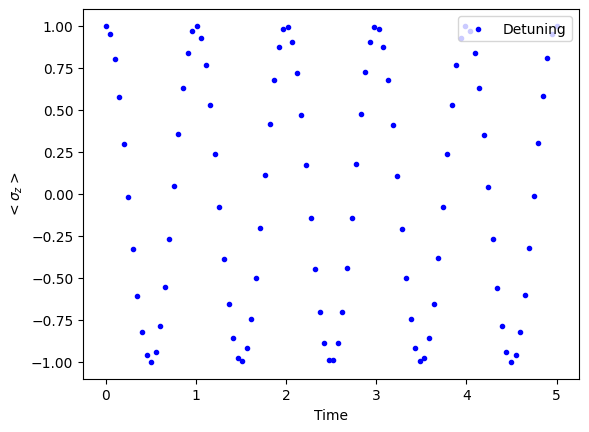

In [21]:
plt.scatter(tlist, res.expect[0], c="b", marker=".", label="Detuning")
plt.xlabel("Time"), plt.ylabel("$<\sigma_z>$")
plt.legend(loc = 'upper right');

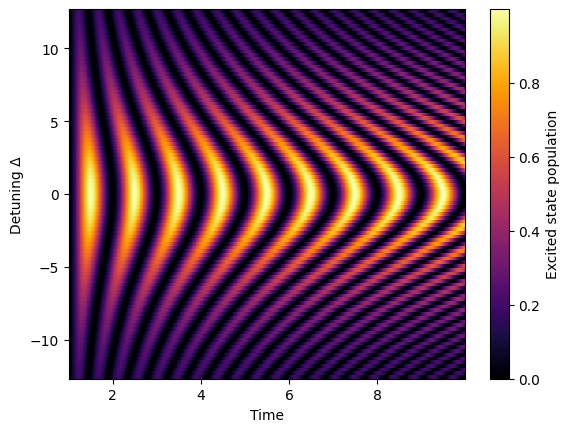

In [22]:
delta_values = np.linspace(-4 * np.pi, 4 * np.pi, 100)

populations = []
for delta in delta_values:
    H = -0.5 * delta * sigmaz() + 0.5 * omega * sigmax()
    result = mesolve(H, psi0, t_array, c_ops, [sigmaz()])
    pop = (1 - np.array(result.expect[0])) / 2                  # excited state population
    populations.append(pop)

populations = np.array(populations)

# plot as 2D heatmap
plt.pcolormesh(t_array, delta_values, populations, cmap='inferno')
#plt.axvline(x = np.pi/omega, color = 'red')
plt.xlabel('Time')
plt.ylabel('Detuning Δ')
plt.colorbar(label='Excited state population')

This plot is known as the Rabi chevron and here is my interpretation of it: The pattern itself arises from the oscillation between the excited state (bright yellow) and the ground state (black regions). As time goes on, these oscillations become quicker and only at low detuning values do we actually reach an excited state. 


Corrections: The oscillations become quicker with higher detuning values, not time ellasped. This is seen in the compression of the oscillations at the top and bottom edges of the plot. At $\Delta = 0$ we have complete population transfer into the excited state, whereas at increasingly high and low detunings, we get less population transfer.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

omega = 1.0       # drive strength
delta = 2.0       # detuning — vary this
omega_R = np.sqrt(omega**2 + delta**2)

H = -0.5 * delta * sigmaz() + 0.5 * omega * sigmax()
psi0 = basis(2, 0)
tlist = np.linspace(0, 4 * np.pi / omega_R, 300)

# measure all three Bloch components
result = mesolve(H, psi0, tlist, [], 
                    [sigmax(), sigmay(), sigmaz()])

bx = result.expect[0]
by = result.expect[1]
bz = result.expect[2]

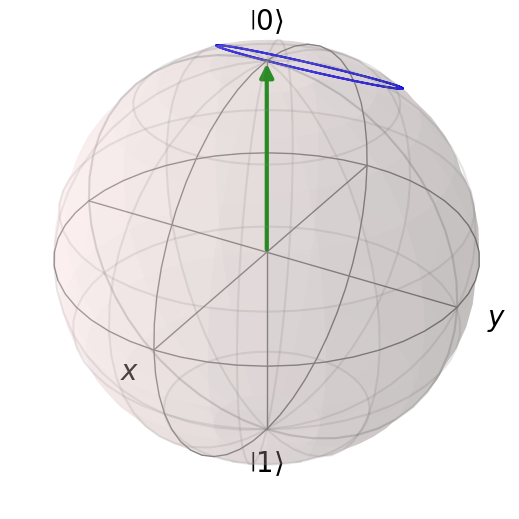

In [24]:
b = Bloch()

# plot the trajectory
b.add_points([bx, by, bz], meth='l')  # 'l' = line

# plot the final state vector
b.add_vectors([bx[-1], by[-1], bz[-1]])

b.show()

Now I've looked at the effects of detuning, dephasing, and relaxation, but it is neccessary to put these together to get a more realistic picture of the noise in the system. We will introduce the thermal collapse operators which are tied to a temperature parameter: 

* $ C_1 = \sqrt{\gamma (n + 1) \sigma_{-}}$

* $ C_2 = \sqrt{\gamma n \sigma_{+}}$

where n is the mean thermal photon number at the qubit frequency:

* $ n = \frac {1}{e^(\hbar \omega_0 / k_B T) - 1}$

In [59]:
# physical parameters
w0 = 1.0      # qubit frequency
g= 0.1        # base relaxation rate
T = 0.5            # temperature (in units where hbar = kB = 1)

# thermal occupation number
def n_bar(temp, omega_0):   
    if T > 0:
     n_bar_val = 1 / (np.exp(omega_0 / temp) - 1)
    else:
        n_bar_val = 0
    return n_bar_val

n = n_bar(T,w0)
H = -0.5 * delta * sigmaz() + 0.5 * omega * sigmax()
psi0 = basis(2,1)
c_ops =  [
    np.sqrt(g) * sigmaz(),
    np.sqrt(g*(n+ 1)) * sigmam(),
    np.sqrt(g*(n))* sigmap()
    ]
result = mesolve(H, psi0, tlist, c_ops, [sigmaz()])

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_58188/3387080921.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$<\sigma_z>$")
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_58188/3387080921.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc = 'upper right')


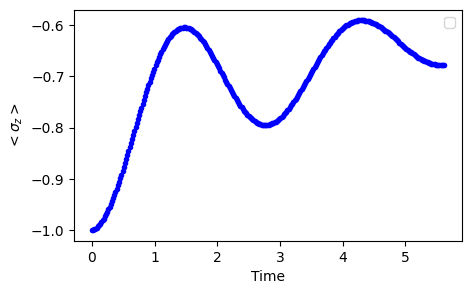

In [60]:
plt.figure(figsize= (5,3))
plt.scatter(tlist, result.expect[0], c="b", marker=".")
plt.xlabel("Time")
plt.ylabel("$<\sigma_z>$")
plt.legend(loc = 'upper right')
plt.show()

In [71]:
# physical parameters
w0 = 1.0      # qubit frequency
g= 0.1        # base relaxation rate

# thermal occupation number
def n_bar(temp, omega_0):   
    if T > 0:
     n_bar_val = 1 / (np.exp(omega_0 / temp) - 1)
    else:
        n_bar_val = 0
    return n_bar_val

T_values = np.array([0.5,1,5,0.0000])

tlist = np.linspace(0, 20, 100)

results = []
for T in T_values: 
    n = n_bar(T,w0)
    c_ops =  [
    np.sqrt(g) * sigmaz(),
    np.sqrt(g*(n+ 1)) * sigmam(),
    np.sqrt(g*(n))* sigmap()
    ]
    result = mesolve(H, psi0, tlist, c_ops, [sigmaz()])
    results.append(result.expect[0])

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/4t/t515wkn52_9_fj_wtsmnsf2w0000gn/T/ipykernel_58188/2118821930.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$<\sigma_z>$")


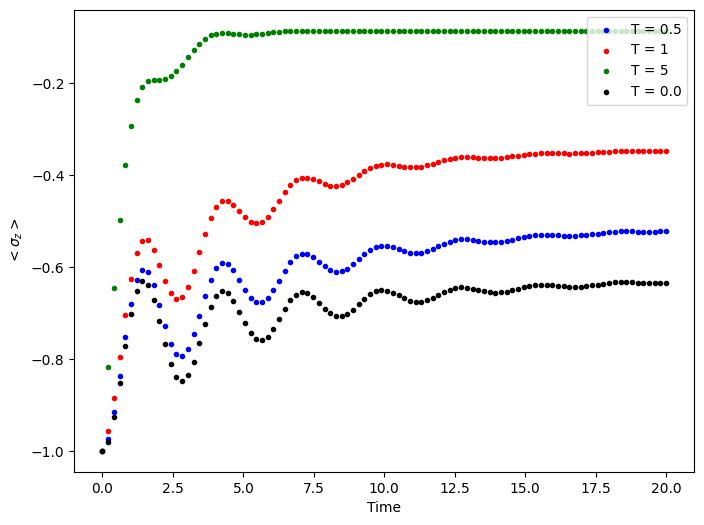

In [73]:
plt.figure(figsize= (8,6))
plt.scatter(tlist, results[0], c="b", marker=".", label = 'T = 0.5')
plt.scatter(tlist, results[1], c="r", marker=".", label = 'T = 1')
plt.scatter(tlist, results[2], c="g", marker=".", label = 'T = 5')
plt.scatter(tlist, results[-1], c="black", marker=".", label = 'T = 0.0')

plt.xlabel("Time")
plt.ylabel("$<\sigma_z>$")
plt.legend(loc = 'upper right')
plt.show()